### Chord Extractor with librosa and chroma analysis
Testing triad detection and then 7th detection in the section of the chord to define the tetrad quality

In [1]:
import os
import librosa
import librosa.display
import numpy as np 
import importlib
import formExtractor as fem
importlib.reload(fem)
import matplotlib.pyplot as plt

In [2]:
def load_audio_files(path):
    audio_files = []
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith(".mp3"):
                audio_files.append(os.path.join(root, file))
    return audio_files

In [3]:
path = '../samples/' 
collection = 'suno_samples'
song_files = os.path.join(path, collection, 'audio')
files = load_audio_files(song_files)
print(len(files))
files

20


['../samples/suno_samples/audio/000201b3-1a93-4023-8b00-94b7c2a0b004.mp3',
 '../samples/suno_samples/audio/0002d6bf-36e5-4f04-a075-5476f06b2c49.mp3',
 '../samples/suno_samples/audio/000364ba-26f7-44d5-9698-b75e322dc8a1.mp3',
 '../samples/suno_samples/audio/0003f586-fd04-477c-b11c-b255269637ad.mp3',
 '../samples/suno_samples/audio/06fd6bd7-de7b-47c2-8340-60e23e8e9727.mp3',
 '../samples/suno_samples/audio/17fc743c-0672-416e-a81b-40c5b6c42f79.mp3',
 '../samples/suno_samples/audio/20bb9468-be6e-4714-b6a4-f6b0296c92cd.mp3',
 '../samples/suno_samples/audio/20be39f5-de0c-435f-8c71-faaa74001f80.mp3',
 '../samples/suno_samples/audio/26536782-2757-42e9-b928-1da617390991.mp3',
 '../samples/suno_samples/audio/2cf8e9fb-f670-4223-89a8-d6bbb83887fd.mp3',
 '../samples/suno_samples/audio/2cfba915-9d1d-41dc-92bb-729118ef6694.mp3',
 '../samples/suno_samples/audio/3ab63037-6dd3-4664-82c7-5845e68d8ee9.mp3',
 '../samples/suno_samples/audio/3ab71537-c748-4027-be25-8d0c309f6f66.mp3',
 '../samples/suno_samples

In [4]:
#2cf8e9fb-f670-4223-89a8-d6bbb83887fd
id = 9
song = files[id]

id_file = song.split('/')[-1].split('.')[0]
song

'../samples/suno_samples/audio/2cf8e9fb-f670-4223-89a8-d6bbb83887fd.mp3'

In [5]:
#song = "../src/test_audio/Djavan - Azul (Ao Vivo).wav"

In [6]:
#Get the tonality of the song

y, sr = librosa.load(song)

# Compute the chroma features using CQT
chroma_cq = librosa.feature.chroma_cqt(y=y, sr=sr)

# Sum chroma features over time to emphasize prominent pitches
chroma_vector = np.sum(chroma_cq, axis=1)
chroma_vector /= np.linalg.norm(chroma_vector)

# Modified Krumhansl-Schmuckler key profiles
major_profile = np.array([6.35, 2.23, 3.48, 2.33, 4.38, 4.09,
                          2.52, 5.19, 2.39, 3.66, 2.29, 2.88])
minor_profile = np.array([6.33, 2.68, 3.52, 5.38, 2.60, 3.53,
                          2.54, 4.75, 3.98, 2.69, 3.34, 3.17])

# Optionally adjust profiles
# minor_profile[0] *= 1.2  # Emphasize tonic in minor

# Normalize the profiles
major_profile /= np.linalg.norm(major_profile)
minor_profile /= np.linalg.norm(minor_profile)

key_names = ['C', 'C#', 'D', 'D#', 'E', 'F',
             'F#', 'G', 'G#', 'A', 'A#', 'B']
correlations = []

for i in range(12):
    # Rotate the key profiles
    major_profile_rotated = np.roll(major_profile, i)
    minor_profile_rotated = np.roll(minor_profile, i)

    # Compute the correlation with adjusted weights
    major_corr = np.dot(chroma_vector, major_profile_rotated) * 0.9
    minor_corr = np.dot(chroma_vector, minor_profile_rotated) * 1.1  # Increase minor influence

    correlations.append({
        'key': key_names[i],
        'mode': 'major',
        'correlation': major_corr
    })
    correlations.append({
        'key': key_names[i],
        'mode': 'minor',
        'correlation': minor_corr
    })

# Find the best matching key
best_match = max(correlations, key=lambda x: x['correlation'])
tonality = f"{best_match['key']} {best_match['mode']}"
print(f"Tonality: {tonality}")

# Sort correlations in descending order
correlations_sorted = sorted(correlations, key=lambda x: x['correlation'], reverse=True)
print("Correlation scores for all keys:")
for corr in correlations_sorted:
    print(f"{corr['key']} {corr['mode']}: {corr['correlation']:.4f}")


Tonality: D minor
Correlation scores for all keys:
D minor: 1.0681
G minor: 1.0618
A minor: 1.0599
E minor: 1.0594
C minor: 1.0514
B minor: 1.0455
F minor: 1.0410
F# minor: 1.0362
D# minor: 1.0303
C# minor: 1.0261
A# minor: 1.0256
G# minor: 1.0240
C major: 0.8621
G major: 0.8615
D major: 0.8574
F major: 0.8571
A# major: 0.8518
A major: 0.8441
D# major: 0.8417
E major: 0.8322
G# major: 0.8274
B major: 0.8241
C# major: 0.8181
F# major: 0.8158


In [7]:
# Correct sharp or flat tonality
# Import your Transposition class
from transposition import Transposition

# Initialize the Transposition object
transposer = Transposition()

# Use the get_alterations_scales method to get alterations
corrected_tonality, alterations, scale = transposer.get_alterations_scales(tonality)

# Print the output
print(f"Tonality: {corrected_tonality}")
print(f"Alterations: {alterations}")
print(f"Scale: {scale}")

tonality = corrected_tonality


Tonality: D minor
Alterations: ['Bb']
Scale: ['D', 'E', 'F', 'G', 'A', 'Bb', 'C']


In [8]:
import triadExtractor as te
triads = te.TriadExtractor(hop_length=1024, scale=scale)
chords = triads.extract_chords(song, threshold=0.05, check_on_beat=True)
chords

[ChordChange(chord='Gm7', timestamp=0.09287981859410431),
 ChordChange(chord='Am7', timestamp=1.6253968253968254),
 ChordChange(chord='C', timestamp=2.6006349206349206),
 ChordChange(chord='Dm7', timestamp=3.111473922902494),
 ChordChange(chord='Cm7', timestamp=5.061950113378685),
 ChordChange(chord='A#', timestamp=6.03718820861678),
 ChordChange(chord='Fmaj7', timestamp=6.548027210884354),
 ChordChange(chord='Gm7', timestamp=7.058866213151927),
 ChordChange(chord='Am7', timestamp=9.47374149659864),
 ChordChange(chord='Cmaj7', timestamp=9.984580498866213),
 ChordChange(chord='Dm7', timestamp=11.00625850340136),
 ChordChange(chord='Dmaj7', timestamp=12.956734693877552),
 ChordChange(chord='Gm', timestamp=13.467573696145125),
 ChordChange(chord='G', timestamp=14.44281179138322),
 ChordChange(chord='Cm', timestamp=14.953650793650795),
 ChordChange(chord='Dmaj7', timestamp=16.904126984126986),
 ChordChange(chord='G', timestamp=17.925804988662133),
 ChordChange(chord='D', timestamp=18.39020

In [9]:
from music21 import key, harmony, roman
from IPython.display import Audio

# Define the key context explicitly as C major
mykey = tonality.split(' ')[0]
mymode = tonality.split(' ')[1]
print(mykey, mymode)
song_key = key.Key(mykey, mymode)

#print(f"Key: {song_key.tonic.name} {song_key.mode}")

#The array contains a dictionary [ChordChange(chord='N', timestamp=0.371519274), ChordChange(chord='C#m', timestamp=0.464399092), save the tuple with the function and its location in the timestamp
functional_harmony = []

for chord_name, timestamp in (chords):
    if chord_name == 'N':
        # Skip any chords labeled as N
        functional_harmony.append(('N', timestamp))
        continue
    else:   
        # Create a ChordSymbol object to correctly interpret chord qualities
        chord_symbol = harmony.ChordSymbol(chord_name)
        
        # Convert the chord symbol to a Roman numeral based on the key
        roman_numeral = roman.romanNumeralFromChord(chord_symbol, song_key)
     
        # Append the Roman numeral and timestamp to the list
        functional_harmony.append((roman_numeral.figure, timestamp))
#print only the chords not the timestamps
functional_chords = [chord[0] for chord in functional_harmony]   
print(functional_chords)

D minor
['iv7', 'v7', 'bVII', 'i7', 'bvii75b3', '#V', 'III7', 'iv7', 'v7', 'bVII#753', 'i7', 'I#75#3', 'iv', 'IV', 'bvii', 'I#75#3', 'IV', 'I', 'iv', '#I', '#i', 'bvii75b3', 'iii7', 'IIIb753', 'iv7', '#I', 'bvii75b3', '#V', 'III7', 'i7', 'I#75#3', 'bvii75b3', 'iv', 'IV', '#V', 'iv7', 'IV#75#3', 'iv7', 'v7', 'bVII', 'i7', 'bvii75b3', 'III7', '#V', '#I', '#IV', 'bvii', 'IV', 'i7', 'v', 'bvii', '#V', '#v', '#i7', '#I', '#IV', 'bvii75b3', 'I#75#3', '#iii7', 'iv7', 'i', 'III7', 'v7', 'i7', 'III7', 'i', 'bVII', 'iv7', 'ii7#53', 'V', 'i', 'V', 'I', 'v7', 'i7', 'vi7#53', 'i', 'V', 'ii7#53', 'i7', 'iv', 'IV', 'bVII', '#V', 'i', 'V', 'v', 'i', 'bVII', 'bvii', 'bVII#753', 'bvii', 'III7', 'i7', 'II#7#5#3', 'I', '#iv', 'v7', 'ii7#53', 'IV', 'VI#7#5#3', 'bvii75b3', 'vi', 'ii7#53', 'IV#75#3', 'iv', 'ii', 'IV', 'ii7#53', 'VI', 'vi', 'v7', '#iii7', 'I', '#iii7', 'VI', 'vi7#53', 'IV', 'vii#7#53', 'V#75#3']


Tempo: 123.046875 BPM


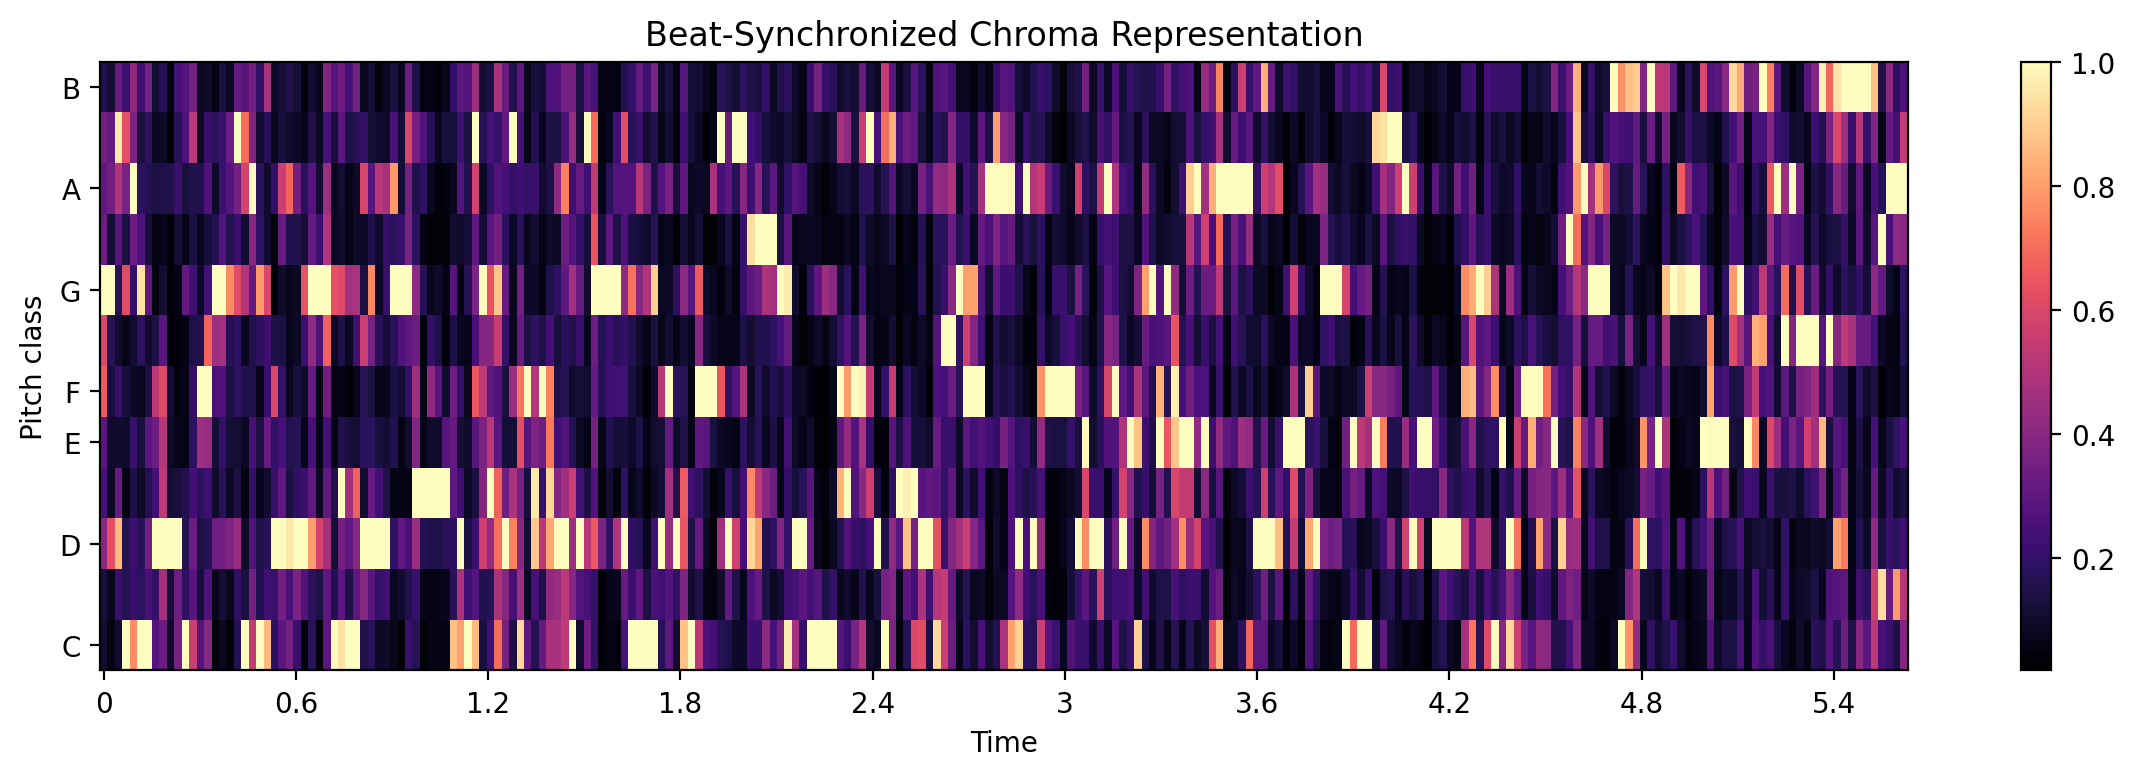

Detected Chords:
['Gmin', 'Gmin', 'A#', 'C', 'Amin', 'C', 'C', 'Dmin', 'Dmin', 'Dmin', 'G', 'Cmin', 'Gmin', 'F', 'F', 'Gmin', 'Gmin', 'Gmin', 'Gmin', 'F', 'Amin', 'C', 'C', 'Dmin', 'Dmin', 'Dmin', 'Dmin', 'Gmin', 'Gmin', 'Gmin', 'G', 'Cmin', 'Cmin', 'Cmin', 'Cmin', 'D', 'G', 'D', 'D', 'Gmin', 'Gmin', 'Gmin', 'D#', 'D#', 'D#min', 'D#min', 'D#', 'C', 'Dmin', 'C', 'F', 'Gmin', 'D#', 'Cmin', 'G', 'A#', 'C', 'F', 'Dmin', 'Dmin', 'A#', 'Dmin', 'D', 'Cmin', 'D', 'A#', 'Gmin', 'G', 'Gmin', 'Gmin', 'Gmin', 'C', 'Amin', 'C', 'C', 'Dmin', 'Dmin', 'Dmin', 'Cmin', 'Cmin', 'Fmin', 'F', 'F', 'A#', 'A#', 'A#', 'A#', 'G#', 'G#', 'G#', 'G#', 'G', 'C', 'Dmin', 'Dmin', 'Cmin', 'Cmin', 'Cmin', 'Cmin', 'A#', 'D#min', 'F', 'A#', 'A#', 'A#', 'F', 'A#', 'D#', 'A#', 'Cmin', 'D', 'D', 'Amin', 'F#min', 'D', 'Gmin', 'Dmin', 'Dmin', 'Dmin', 'Amin', 'Amin', 'Amin', 'Amin', 'Dmin', 'A', 'Dmin', 'F', 'F', 'F', 'Fmin', 'F', 'Dmin', 'Emin', 'Dmin', 'Dmin', 'Dmin', 'Dmin', 'Dmin', 'A', 'C', 'Gmin', 'G', 'Emin', 'Emin', '

In [10]:
import ChordChromogram as ca

analyzer = ca.ChordAnalyzer(song)
analyzer.analyze_chords()
analyzer.visualize_chroma()
analyzer.print_chords()

bpm = analyzer.get_bpm()
print(f"BPM: {bpm}")

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import librosa

def visualize_direct_chords(song_path, chord_data, title="Chord Progression Timeline"):
    """
    Visualize chords over time using direct chord names from triadExtractor.
    
    Parameters:
    song_path (str): Path to the audio file
    chord_data (list): List of tuples containing (chord, timestamp) from triadExtractor
    title (str): Title for the visualization
    """
    # Load the audio file
    y, sr = librosa.load(song_path)
    
    # Get song duration
    duration = librosa.get_duration(y=y, sr=sr)
    
    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), gridspec_kw={'height_ratios': [1, 3]})
    
    # Plot waveform on top subplot
    times = np.linspace(0, duration, len(y))
    ax1.plot(times, y, color='gray', alpha=0.5)
    ax1.set_title("Audio Waveform")
    ax1.set_xlim(0, duration)
    ax1.set_ylabel("Amplitude")
    ax1.grid(True, alpha=0.3)
    
    # Plot chord timeline on bottom subplot
    ax2.set_title("Chord Progression")
    ax2.set_xlabel("Time (seconds)")
    ax2.set_ylabel("Chords")
    ax2.set_xlim(0, duration)
    
    # Extract chord names and timestamps
    # Filter out 'N' chords (no chord)
    filtered_chords = [(chord, time) for chord, time in chord_data if chord != 'N']
    chord_names = [c[0] for c in filtered_chords]
    timestamps = [t[1] for t in filtered_chords]
    
    # Add an extra timestamp at the end of the song for the last chord
    timestamps.append(duration)
    
    # Get unique chords to create y-axis labels
    unique_chords = list(dict.fromkeys(chord_names))
    
    # Create a mapping from chord names to y positions
    chord_positions = {chord: i for i, chord in enumerate(unique_chords)}
    
    # Set y-axis limits and ticks
    ax2.set_ylim(-1, len(unique_chords))
    ax2.set_yticks(range(len(unique_chords)))
    ax2.set_yticklabels(unique_chords)
    
    # Color map for variety
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_chords)))
    
    # Draw colored patches for each chord segment
    for i in range(len(chord_names)):
        start_time = timestamps[i]
        end_time = timestamps[i+1] if i+1 < len(timestamps) else duration
        
        y_pos = chord_positions[chord_names[i]]
        rect = patches.Rectangle(
            (start_time, y_pos - 0.4),
            end_time - start_time,
            0.8,
            linewidth=1,
            edgecolor='black',
            facecolor=colors[y_pos % len(colors)],
            alpha=0.7
        )
        ax2.add_patch(rect)
        
        # Add chord text if the segment is wide enough
        if end_time - start_time > duration / 50:
            ax2.text(
                (start_time + end_time) / 2,
                y_pos,
                chord_names[i],
                horizontalalignment='center',
                verticalalignment='center',
                fontsize=8
            )
    
    # Add vertical lines at chord changes
    for timestamp in timestamps:
        ax1.axvline(x=timestamp, color='r', linestyle='--', alpha=0.3)
        ax2.axvline(x=timestamp, color='r', linestyle='--', alpha=0.3)
    
    # Add grid lines
    ax2.grid(True, axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle(title, fontsize=16)
    plt.subplots_adjust(top=0.9)
    plt.figure(1)
    plt.show()
    
    return fig


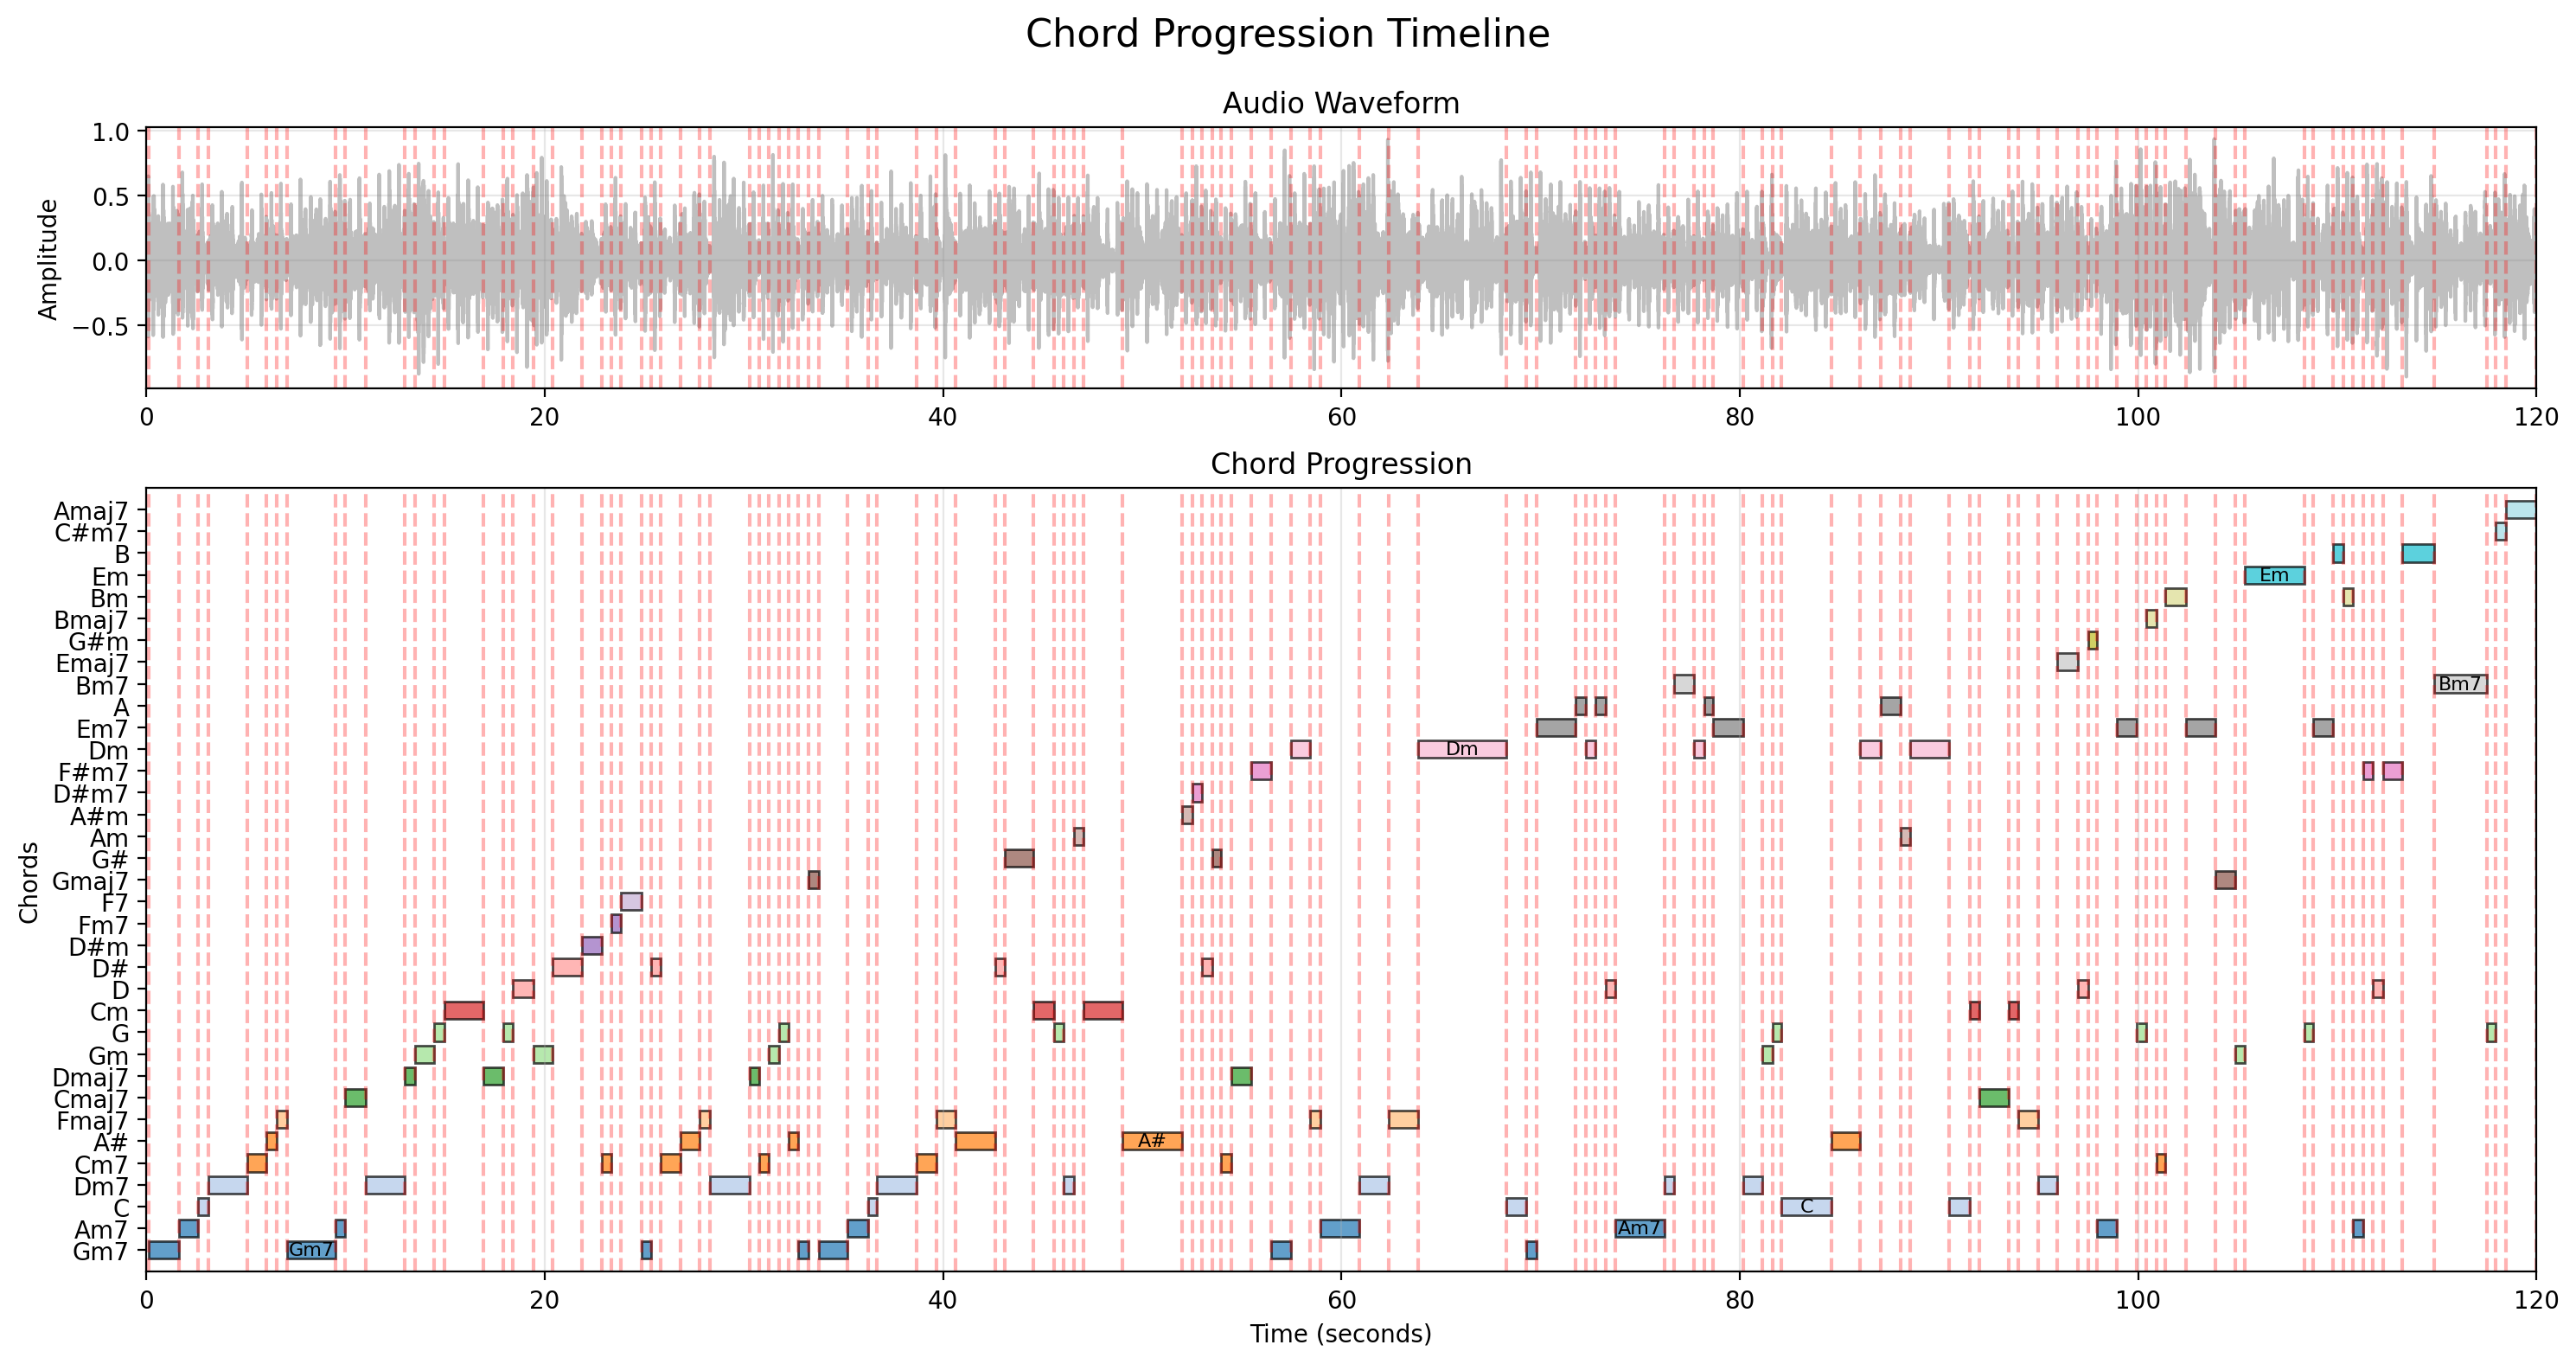

In [12]:

# First visualization - shows all unique chords
chord_timeline = visualize_direct_chords(song, chords, title="Chord Progression Timeline")

In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.transforms as transforms

def get_constant_beats(song_path, bpm, start_time=0.0):
    """
    Generate constant-length beats based on BPM.
    
    Parameters:
    song_path (str): Path to the audio file
    bpm (float): Beats per minute of the song
    start_time (float): Time offset for the first beat
    
    Returns:
    list: List of timestamps indicating beat lines
    dict: Additional information including duration
    """
    # Load the audio file
    y, sr = librosa.load(song_path)
    
    # Get song duration
    duration = librosa.get_duration(y=y, sr=sr)
    
    # Calculate beat duration in seconds
    beat_duration = 60 / bpm
    
    # Generate evenly spaced beats from start_time to the end of the song
    beats = np.arange(start_time, duration + beat_duration, beat_duration)
    
    return beats.tolist(), {'duration': duration, 'beat_duration': beat_duration}

def get_chord_quality(chord_name):
    """
    Determine the quality of a chord for coloring purposes.
    Preserves the exact chord name but categorizes it for coloring.
    
    Parameters:
    chord_name (str): The name of the chord
    
    Returns:
    str: The quality category of the chord
    color: The corresponding color
    """
    chord_lower = chord_name.lower()
    
    # Major or Major 7th chords (orange)
    if 'maj7' in chord_lower or 'maj' in chord_lower or (chord_lower[-1].isalpha() is False and 'm' not in chord_lower and '7' not in chord_lower):
        return "Major", '#FF9933'  # Orange
    
    # Minor or Minor 7th chords (light blue)
    elif 'm7' in chord_lower or 'm' in chord_lower or 'min' in chord_lower:
        return "Minor", '#66B2FF'  # Light blue
    
    # Dominant chords (white)
    elif '7' in chord_lower and 'maj7' not in chord_lower and 'm7' not in chord_lower:
        return "Dominant", '#FFFFFF'  # White
    
    # Diminished or half-diminished chords (purple)
    elif 'dim' in chord_lower or 'ø' in chord_lower or 'o' in chord_lower:
        return "Diminished", '#9966CC'  # Purple
    
    # Augmented chords (darker orange)
    elif 'aug' in chord_lower or '+' in chord_lower:
        return "Augmented", '#CC6600'  # Darker orange
    
    # Default color for unrecognized chord types
    else:
        return "Other", '#CCCCCC'  # Gray

def visualize_beats(chords, song_path, bpm, beats_per_view=32, start_beat=0, start_time=0.0):
    """
    Visualize a limited set of beats with chord progressions.
    Chord names are displayed vertically (90° rotation) and centered.
    
    Parameters:
    chords (list): List of tuples containing (chord, timestamp)
    song_path (str): Path to the audio file
    bpm (float): Beats per minute of the song
    beats_per_view (int): Number of beats to show in visualization
    start_beat (int): Index of the first beat to display
    start_time (float): Time offset for the first beat
    
    Returns:
    figure: Matplotlib figure object
    """
    # Generate constant-length beats
    all_beats, info = get_constant_beats(song_path, bpm, start_time)
    duration = info['duration']
    beat_duration = info['beat_duration']
    total_beats = len(all_beats)
    
    # Validate start_beat
    if start_beat < 0:
        start_beat = 0
    if start_beat >= total_beats:
        start_beat = max(0, total_beats - beats_per_view)
    
    # Calculate end beat
    end_beat = min(start_beat + beats_per_view, total_beats)
    
    # Get time range for our view - CRITICAL FOR CORRECT CHORD DISPLAY
    start_time_view = all_beats[start_beat] if start_beat < len(all_beats) else 0
    if end_beat < len(all_beats):
        end_time_view = all_beats[end_beat-1]
    else:
        end_time_view = duration
    
    # Calculate adaptive sizing parameters based on beats_per_view
    # Scale figure width with beat count
    fig_width = min(30, max(12, beats_per_view / 10))
    
    # Scale font size inversely with beat count using square root for more gradual reduction
    base_font = 10  # Base font size for standard view (32 beats)
    scale_factor = np.sqrt(32 / beats_per_view)
    chord_font_size = max(4, base_font * scale_factor)  # Never go below 4pt
    beat_font_size = max(3, 8 * scale_factor)  # Even smaller for beat numbers
    
    # Scale text box padding with font size
    padding_scale = max(0.1, min(0.3, 0.3 * (32 / beats_per_view)))
    
    print(f"View: {beats_per_view} beats | Figure width: {fig_width:.1f} | Font: {chord_font_size:.1f}pt")
    print(f"Time range: {start_time_view:.2f}s to {end_time_view:.2f}s")
    
    # Create figure with appropriate width
    fig, ax = plt.subplots(figsize=(fig_width, 4), dpi=300)
    
    textSize = 10
    
    # Set up the plot
    ax.set_xlim(start_time_view, end_time_view)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Time (seconds)", fontsize=textSize)
    ax.set_yticks([])
    ax.set_title(f"Beats {start_beat+1}-{end_beat} (BPM: {bpm})", fontsize=textSize)
    
    # Plot beat lines - show every beat for small ranges, or every nth beat for large ranges
    beat_stride = max(1, beats_per_view // 100)  # Show fewer beat numbers for large ranges
    for i in range(start_beat, min(start_beat + beats_per_view + 1, total_beats)):
        if i < len(all_beats):
            beat_time = all_beats[i]
            if beat_time <= end_time_view:
                # Draw all beat lines but only label some of them
                ax.axvline(x=beat_time, color='black', linestyle='-', alpha=0.3, linewidth=0.5)
                
                # Only show labels for some beats when displaying many
                if i % beat_stride == 0:
                    ax.text(beat_time, 0.95, str(i+1), 
                            horizontalalignment='center', 
                            verticalalignment='top',
                            fontsize=beat_font_size,
                            color='gray')
    
    # Find all chords that occur within our time window
    chord_names = [chord for chord, _ in chords]
    chord_times = [time for _, time in chords]
    
    # Collect all visible chord indices
    visible_chord_indices = []
    
    # First, include the chord active at the start (if any)
    if chord_times and start_time_view >= chord_times[0]:
        prev_indices = [i for i, time in enumerate(chord_times) if time <= start_time_view]
        if prev_indices:
            visible_chord_indices.append(max(prev_indices))
    
    # Then add all chords that start within our view window
    for i, time in enumerate(chord_times):
        if start_time_view <= time < end_time_view and i not in visible_chord_indices:
            visible_chord_indices.append(i)
    
    # Sort the indices to ensure correct order
    visible_chord_indices.sort()
    
    # Get the visible chords and their timestamps
    visible_chords = [chord_names[i] for i in visible_chord_indices]
    visible_times = [chord_times[i] for i in visible_chord_indices]
    
    # Add the end time as the last boundary
    if visible_times:
        visible_times.append(end_time_view)
    
    print(f"Found {len(visible_chords)} chords in current view")
    
    # If no chords are visible, use a placeholder
    if not visible_chords:
        visible_chords = ["N.C."]  # "No Chord" indicator
        visible_times = [start_time_view, end_time_view]
    
    # Draw chord regions and labels
    for i in range(len(visible_chords)):
        # Skip if we're at the last time (which is just the end boundary)
        if i >= len(visible_times) - 1:
            break
            
        # Get this chord's time range
        start_time_chord = max(visible_times[i], start_time_view)
        end_time_chord = min(visible_times[i+1], end_time_view)
        
        # Calculate chord segment width
        segment_width = end_time_chord - start_time_chord
        
        # Ensure segment width is at least minimum size to be visible
        if segment_width <= 0:
            continue
            
        # Get chord quality and color
        quality, color = get_chord_quality(visible_chords[i])
        
        # Draw colored rectangle for the chord
        rect = patches.Rectangle(
            (start_time_chord, 0.1),
            segment_width,
            0.8,
            linewidth=0.75,
            edgecolor='#333333',
            facecolor=color if visible_chords[i] != "N.C." else "#EEEEEE",  # Use light gray for "No Chord"
            alpha=0.7
        )
        ax.add_patch(rect)
        
        # Always add chord text, scaled appropriately for the view range
        chord_x = start_time_chord + segment_width / 2
        
        # Create text object with appropriately scaled font size
        text = ax.text(
            chord_x, 0.5,
            visible_chords[i],
            rotation=90,
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=chord_font_size,
            color='black',
            bbox=dict(
                boxstyle=f"round,pad={padding_scale}",
                fc="white",
                ec="none",
                alpha=0.6
            ),
            zorder=100  # Ensure text is on top
        )
    
    # Create a legend for chord quality types
    legend_elements = [
        patches.Patch(facecolor='#FF9933', edgecolor='black', alpha=0.7, label='Major chords'),
        patches.Patch(facecolor='#66B2FF', edgecolor='black', alpha=0.7, label='Minor chords'),
        patches.Patch(facecolor='#FFFFFF', edgecolor='black', alpha=0.7, label='Dominant chords'),
        patches.Patch(facecolor='#9966CC', edgecolor='black', alpha=0.7, label='Diminished chords'),
        patches.Patch(facecolor='#CC6600', edgecolor='black', alpha=0.7, label='Augmented chords')
    ]
    
    # Add the legend below the chart - use smaller font for large beat ranges
    legend_font = max(6, min(9, 9 * scale_factor))
    ax.legend(
        handles=legend_elements,
        loc='upper center', 
        bbox_to_anchor=(0.5, -0.13),
        ncol=5,
        frameon=True,
        fontsize=legend_font
    )
    
    plt.tight_layout()
    
    # Add navigation information
    plt.figtext(0.01, 0.01, f"Beats {start_beat+1}-{end_beat} of {total_beats}", 
                fontsize=max(6, 8*scale_factor), color='gray')
    
    max_pages = (total_beats // beats_per_view) + (1 if total_beats % beats_per_view > 0 else 0)
    current_page = (start_beat // beats_per_view) + 1
    plt.figtext(0.99, 0.01, f"Page {current_page}/{max_pages}", 
                fontsize=max(6, 8*scale_factor), color='gray', ha='right')
    
    return fig

def estimate_start_time(chords, bpm):
    """
    Estimate the start time offset to align beats with chord changes.
    
    Parameters:
    chords (list): List of tuples containing (chord, timestamp)
    bpm (float): Beats per minute of the song
    
    Returns:
    float: Estimated start time offset
    """
    # Get first few chord changes
    if not chords:
        return 0.0
        
    early_changes = [time for _, time in chords[:min(5, len(chords))]]
    
    if not early_changes:
        return 0.0
    
    # Calculate beat duration
    beat_duration = 60 / bpm
    
    # Try different offsets and see which aligns best with chord changes
    best_offset = 0.0
    best_score = float('inf')
    
    for test_offset in np.linspace(0, beat_duration, 20):
        # Generate theoretical beat lines with this offset
        theoretical_beats = np.arange(test_offset, early_changes[-1] + beat_duration, beat_duration)
        
        # Calculate total distance between chord changes and nearest beat lines
        total_distance = 0
        for change in early_changes:
            nearest_beat_idx = np.argmin(np.abs(theoretical_beats - change))
            total_distance += abs(theoretical_beats[nearest_beat_idx] - change)
        
        if total_distance < best_score:
            best_score = total_distance
            best_offset = test_offset
    
    return best_offset

def visualize_beats_sequence(chords, song_path, bpm, beats_per_view=32):
    """
    Create a sequence of visualizations, each showing a limited set of beats.
    
    Parameters:
    chords (list): List of tuples containing (chord, timestamp)
    song_path (str): Path to the audio file
    bpm (float): Beats per minute of the song
    beats_per_view (int): Number of beats to show in each visualization
    """
    # Estimate start time offset
    start_time = estimate_start_time(chords, bpm)
    
    # Generate constant-length beats
    all_beats, info = get_constant_beats(song_path, bpm, start_time)
    duration = info['duration']
    beat_duration = info['beat_duration']
    estimated_total_beats = int(np.ceil(duration / beat_duration))
    
    figures = []
    for page in range((estimated_total_beats // beats_per_view) + 1):
        start_beat = page * beats_per_view
        if start_beat >= estimated_total_beats:
            break
            
        fig = visualize_beats(chords, song_path, bpm, beats_per_view, start_beat, start_time)
        figures.append(fig)
        plt.show()
    
    return figures

View: 64 beats | Figure width: 12.0 | Font: 7.1pt
Time range: 0.18s to 30.90s
Found 32 chords in current view


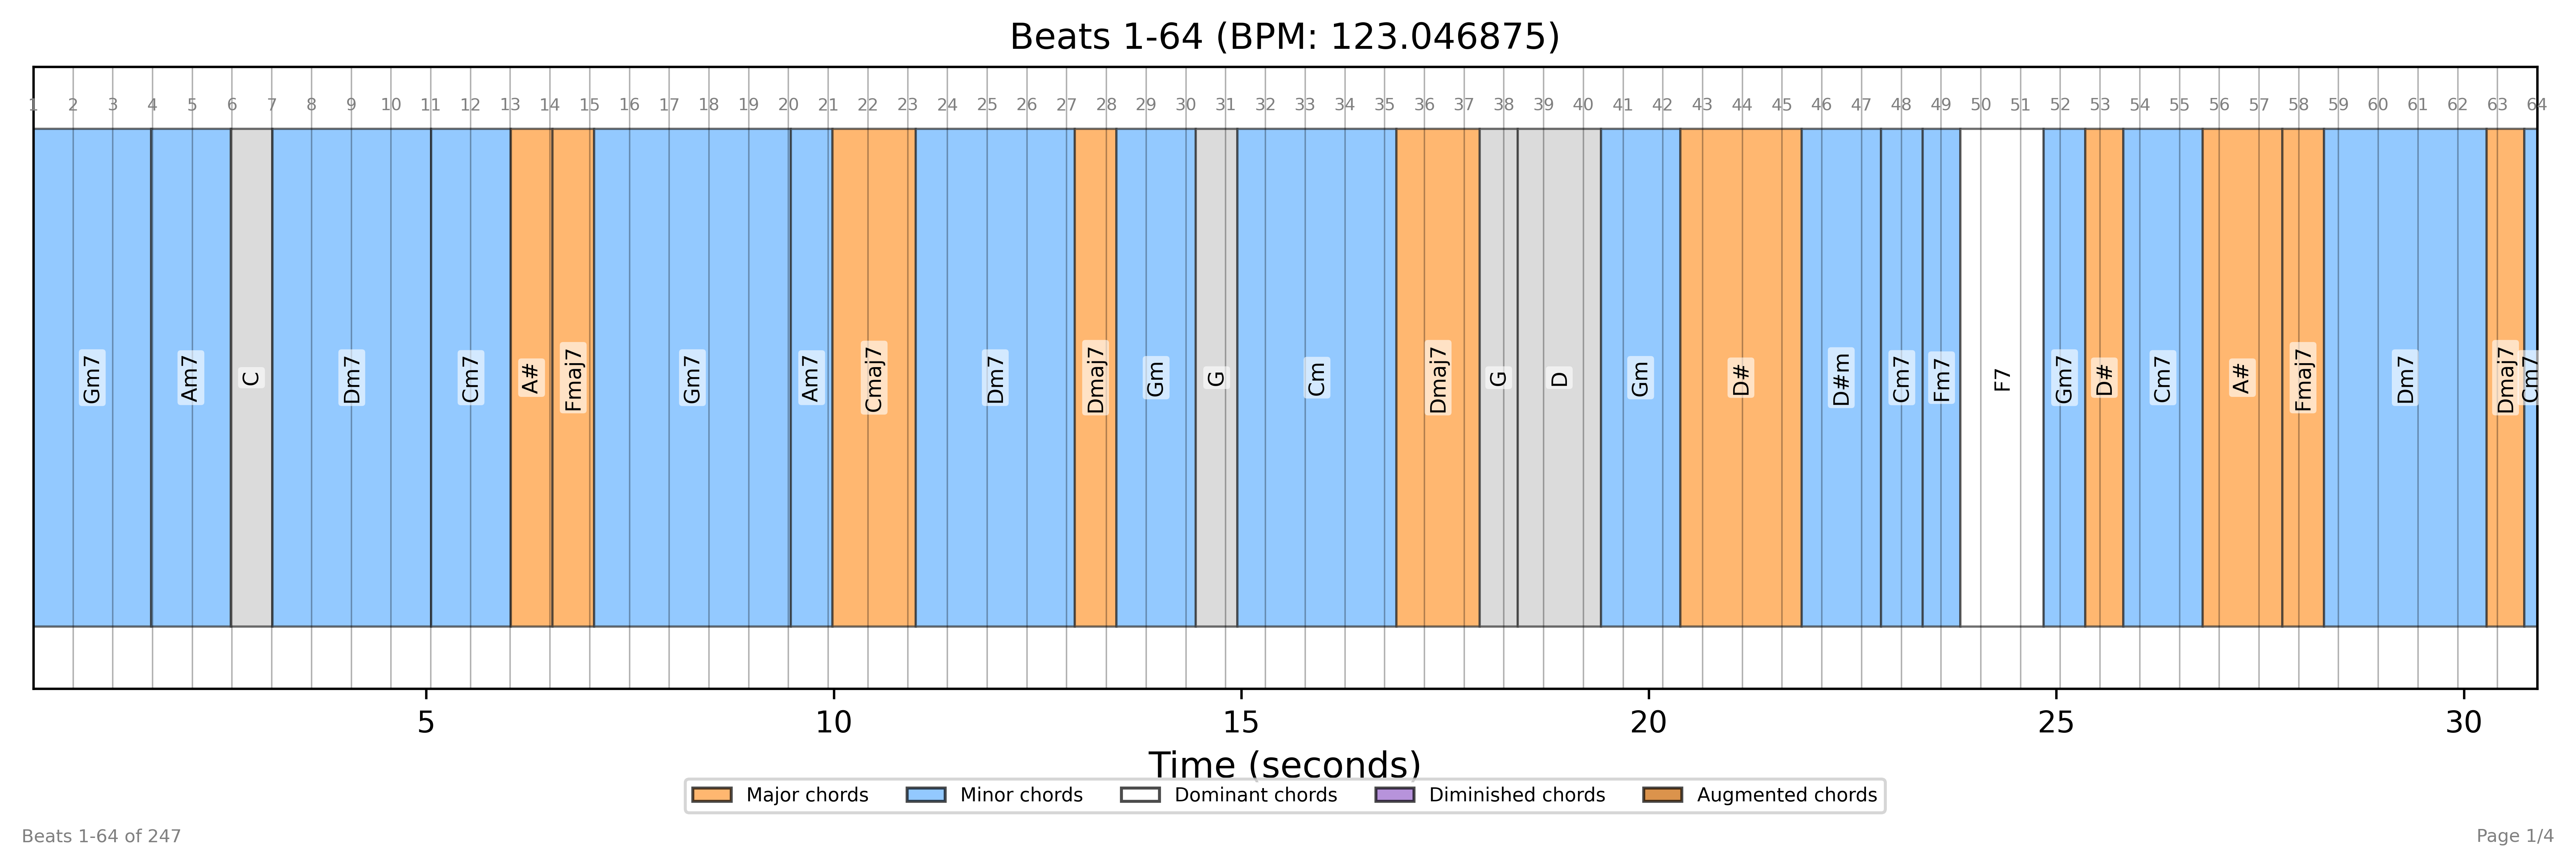

In [66]:
from IPython.display import Audio, display

# First, estimate the best start time to align beats with chord changes
start_time = estimate_start_time(chords, bpm)

# Generate visualization with constant beat lengths
visualize_beats(chords, song, bpm, beats_per_view=64, start_beat=0, start_time=start_time)

# Create an audio widget
audio = Audio(song)

# Display the audio player
display(audio)